For this asssessment I'm using the dataset from Kaggle and having it evaluated using these following Imports. Although the data maybe old it is really useful for it is large enough and shows good patterns for my work in IDS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

In [ ]:
kdd_columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'difficulty_level'
]

Using pandas read csv to load my data

In [ ]:
def load_kdd_data(file_path):
    df = pd.read_csv(file_path, header=None, names=kdd_columns)
    df['difficulty_level'] = pd.to_numeric(df['difficulty_level'], errors='coerce')
    return df

Loading the two file
1. train_df = for training the simulation
2. test_df = for testing the trained simulation

In [ ]:
train_df = load_kdd_data('/content/KDDTrain+.txt')
test_df = load_kdd_data('/content/KDDTest+.txt')

Checking if the data I've loaded is proper and expected
1. the first 5 rows with the head
2. types of data features
3. the amount of missing values

In [ ]:
print("Training data shape:", train_df.shape)
print("\nFirst 5 rows:")
display(train_df.head())

print("\nData types:")
print(train_df.dtypes)

print("\nMissing values:")
print(train_df.isnull().sum().sum())

Training data shape: (55296, 43)

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20.0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19.0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21.0
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21.0



Data types:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_r

Dropping the data type difficulty level as it will create a bias in the scene and without it it also makes it simple

In [ ]:
train_df = train_df.drop('difficulty_level', axis=1)
test_df = test_df.drop('difficulty_level', axis=1)

This process simplifies the intrusion detection task by turning column with many attack types into a simpler column with binary categories : normal(0) or attacked(1)

In [ ]:
train_df['label'] = train_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label'] = test_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

Next step was to targer categorial data into numerical values so the trained ML can process it.
1. So in the dataset we have some categorial data which we can turn into numerical values using LabelEncoder()
2. and for consistency's sake I'll be using same number to define same thing in both the datasets for example (html=1, udp=2, ftp=3)

In [ ]:
categorical_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in categorical_cols:
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)

    all_values = pd.concat([train_df[col], test_df[col]], ignore_index=True).unique()
    le.fit(all_values)

    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

I'll be dropping some more data labels
1. attack_type= to prevent target leakage and force the model to learn from other features
2. label= cause its target variable and including doesnt make sense beacuse its the answer we want this model to learn

In [ ]:
X_train = train_df.drop(['attack_type', 'label'], axis=1)
y_train = train_df['label']

X_test = test_df.drop(['attack_type', 'label'], axis=1)
y_test = test_df['label']

This step makes use of StandardScaler from the scikit-learn lib which transforms the numeric value so that it doesnt have any zero mean to prevent the features with larger values from domination the model.

In [ ]:
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=['number']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nPreprocessed data ready for modeling!")
print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)


Preprocessed data ready for modeling!
Training features shape: (55296, 41)
Test features shape: (22544, 41)


In this step i initialize a RandomForest model with some configuration and the two train axis i.e x the data column and y the answer colmun

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Here we two sets of output from the training which are
1. y_pred the predicted answer that is the output from the 1st line and
2. y_test the actual answer from the model that has alread been tested


---


and we compare those two in the second step

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.97      0.80      9711
           1       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544



This code aims to create a visual representation of how many times each type of attack appears in the training dataset.


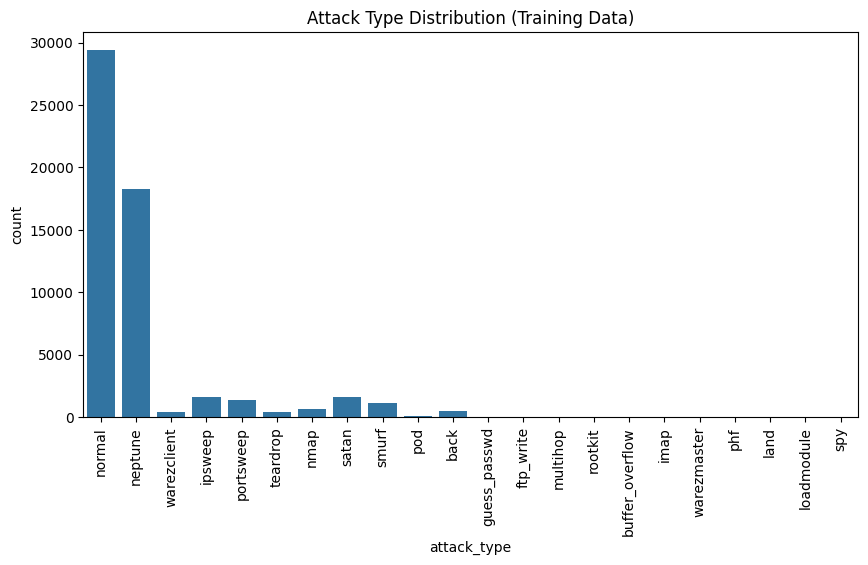

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='attack_type', data=train_df)
plt.title('Attack Type Distribution (Training Data)')
plt.xticks(rotation=90)
plt.show()

Next we will get a better visualization for the less common attack types by:
 1. Setting the size of the plot to be small
 2. creating the bar plot using sns.countplot
 3. Adding the title to the plot
 4. rotating the x-axis label for better readbility.

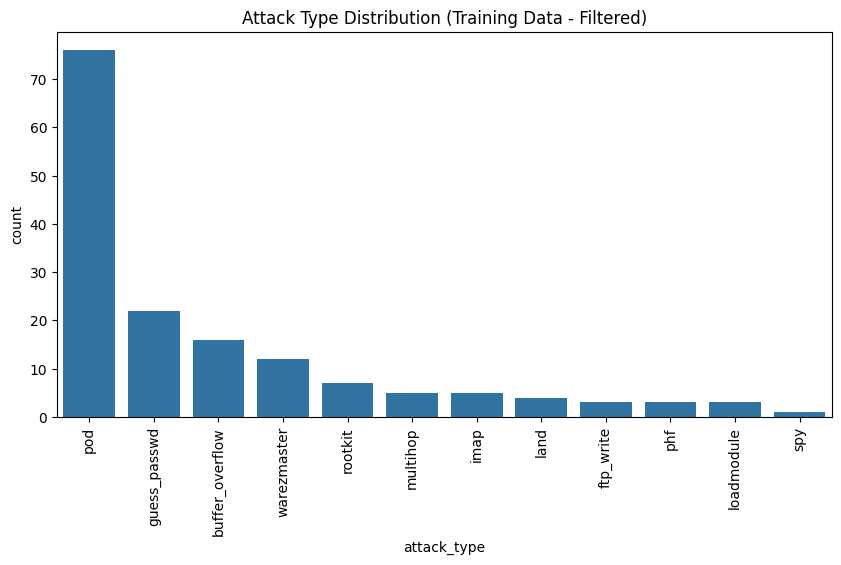

In [ ]:
attack_counts = train_df['attack_type'].value_counts()
filtered_attacks = attack_counts[attack_counts < 300].index
filtered_df = train_df[train_df['attack_type'].isin(filtered_attacks)]
plt.figure(figsize=(10, 5))
sns.countplot(x='attack_type', data=filtered_df, order=filtered_attacks)
plt.title('Attack Type Distribution (Training Data - Filtered)')
plt.xticks(rotation=90)
plt.show()

This following code createda heat map showing the co-relation between the numerical featurs in the training dataset using a color-coded heatmap.

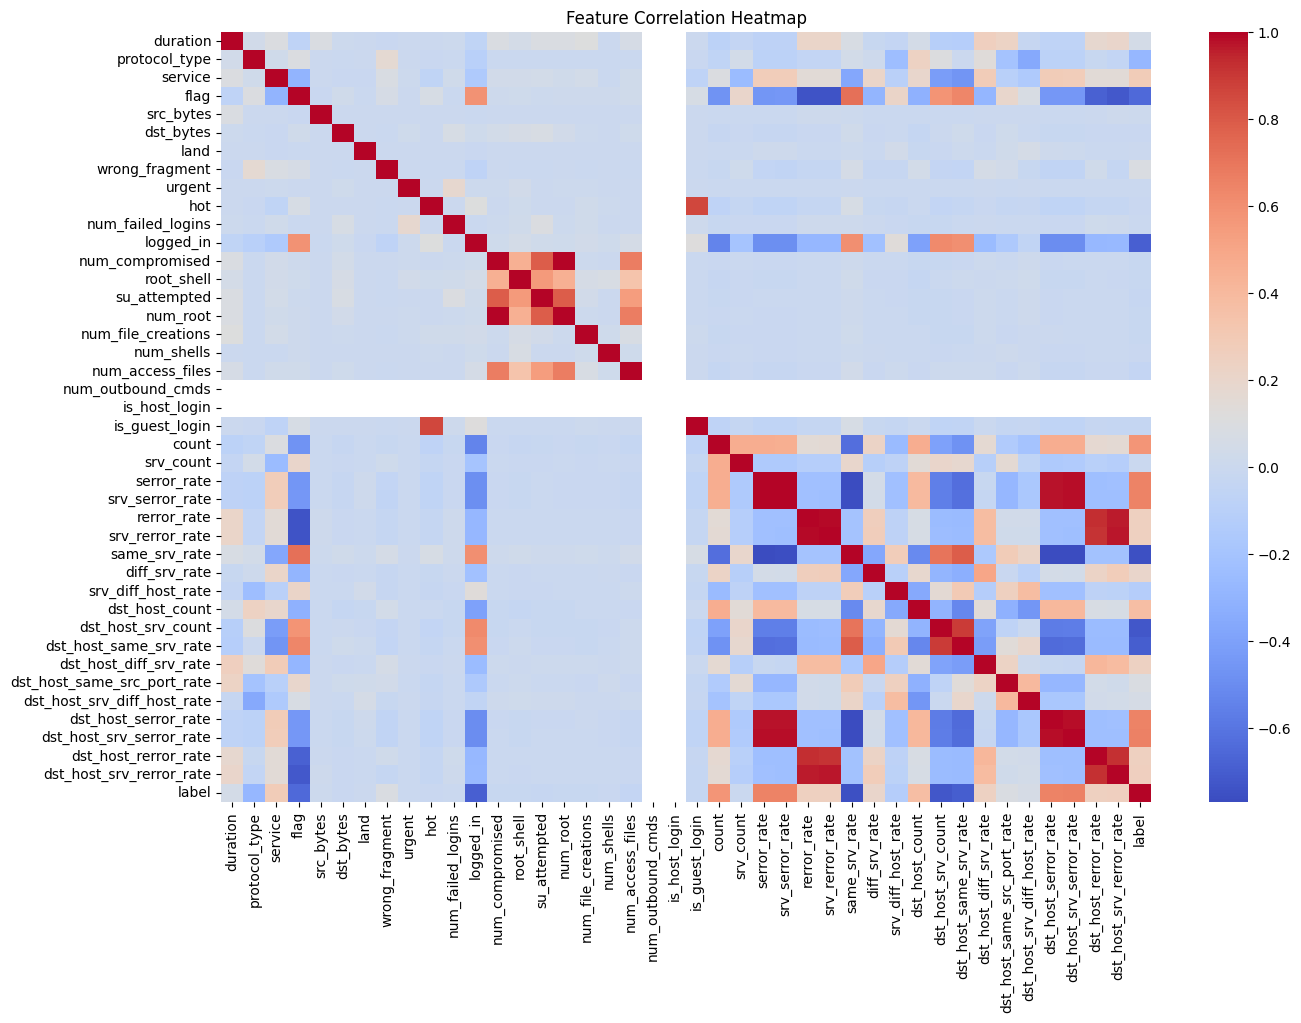

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(train_df.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

So for the following code we need to know what a hyperparameter and grid search is. Hyperparameters are settings that control the learning process of a machine learning model and GridSearchCV is a technique for systematically searching through a range of hyperparameter values to find the combination that yields the best model performance.

And so the following code uses both of those to automatically find the best hyperparameter setting for a randomforestclassifier.

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [ ]:

models = {
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}

1. Using **pandas** and **sklearn.impute** for this step to figuer out the mean could be changed for median or most_frequent
2. after that we fit on the training data and transform both training and testing data for the figures in Next step

In [ ]:
imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

Training and evaluation for the diagrams - confusion matrix for Random Forest and SVM using MatploitLib

              precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



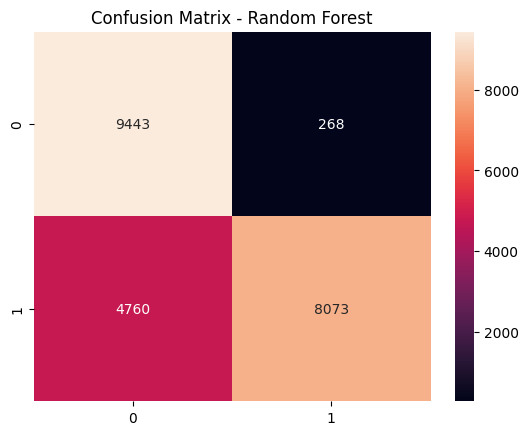

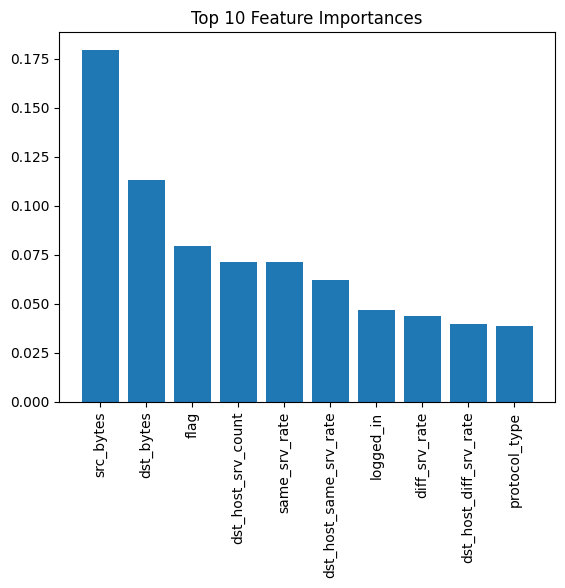

              precision    recall  f1-score   support

           0       0.66      0.98      0.79      9711
           1       0.98      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544



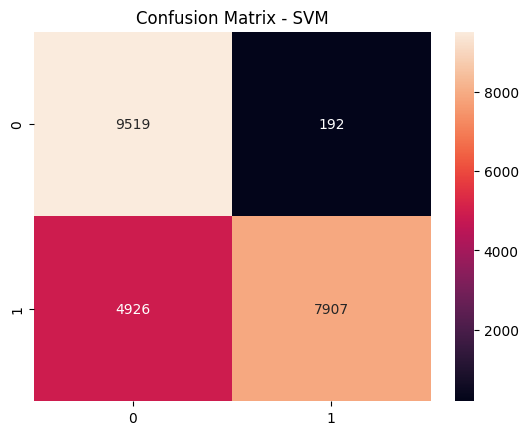

              precision    recall  f1-score   support

           0       0.65      0.93      0.77      9711
           1       0.93      0.62      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.81      0.76      0.75     22544



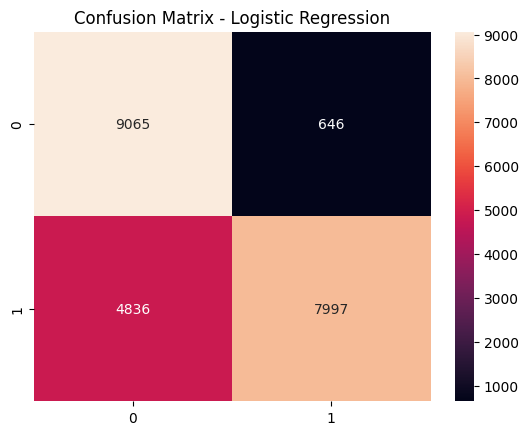

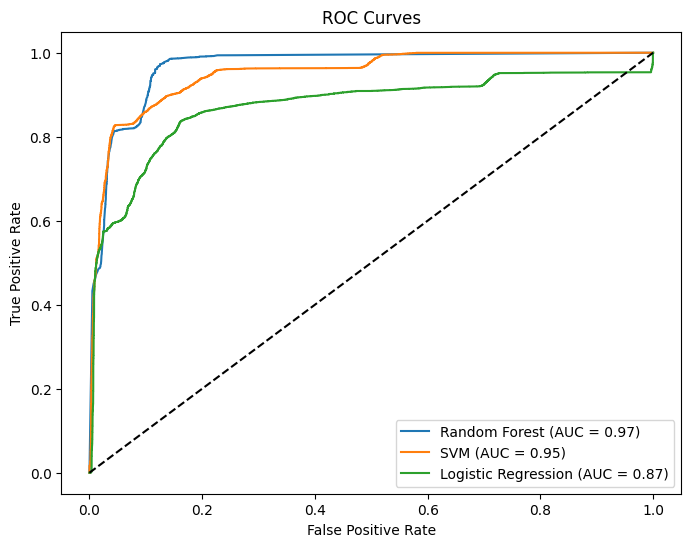

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}

param_grids = {
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [None, 20], 'min_samples_split': [2, 5]},
    'SVM': {'C': [1, 10], 'gamma': [0.01, 0.1]},
    'Logistic Regression': {'C': [0.1, 1, 10]}
}
# Model and Hyperparameter Definition
roc_data = {}
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grids[name], cv=3, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
        #Model Training and Selection
    y_pred = best_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    y_proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)
        # Model Evaluation and Visualization
    if name == 'Random Forest':
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1][:10]
        plt.figure()
        plt.title('Top 10 Feature Importances')
        plt.bar(range(10), importances[indices], align='center')
        plt.xticks(range(10), X_train.columns[indices], rotation=90)
        plt.show()
        #Feature Importance for Random Forest
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()